# Machine Learning Analysis
## The Economic Aftershocks: Analyzing the Impact of Major Earthquakes on National Recovery

**Author:** Betül Merey (33963)  
**Course:** DSA 210 — Introduction to Data Science  

---

This notebook tests **H3**: A non-linear relationship exists between earthquake impact and economic indicators, which can be modeled more accurately using ensemble learning (Random Forest) than linear methods.

**Target variable:** `recovery_class` — Fast (1 year), Medium (2-3 years), Slow (4+ years)

**Models compared:**
- Logistic Regression (linear baseline)
- Random Forest (H3 claim)

**Evaluation:** Stratified 5-fold cross-validation + paired Wilcoxon significance test

In [25]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/DSA210_PROJ')
print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/DSA210_PROJ


In [26]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      cross_val_predict, GridSearchCV)
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy import stats

warnings.filterwarnings('ignore')

INCOME_ORDER = ["Low", "Lower-Middle", "Upper-Middle", "High"]
PALETTE = {"Low":"#d62728", "Lower-Middle":"#ff7f0e",
           "Upper-Middle":"#2ca02c", "High":"#1f77b4"}
RNG = 42
np.random.seed(RNG)
print("Libraries loaded.")

Libraries loaded.


## 1. Load & Prepare Data

In [27]:
df = pd.read_csv('data/processed/merged_dataset.csv')

df["income_group"] = pd.Categorical(
    df["income_group"], categories=INCOME_ORDER, ordered=True
)

print(f"Dataset: {len(df)} rows x {len(df.columns)} columns")
print(f"\nrecovery_years - non-null: {df['recovery_years'].notna().sum()}")
print(f"\nValue counts:")
print(df['recovery_years'].value_counts().sort_index())

Dataset: 959 rows x 17 columns

recovery_years - non-null: 695

Value counts:
recovery_years
1.0    461
2.0    108
3.0     62
4.0     42
5.0     22
Name: count, dtype: int64


## 2. Target Variable — 3-Class Classification

`recovery_years` is bounded between 1 and 5 (events that never recovered are NaN). The distribution is heavily skewed:

| recovery_years | count | share |
|---|---|---|
| 1 | ~330 | ~68% |
| 2 | ~70 | ~14% |
| 3 | ~46 | ~10% |
| 4 | ~27 | ~6% |
| 5 | ~12 | ~2% |

Treating this as a continuous variable is misleading: an RMSE of 0.7 means almost nothing when the value can only be 1, 2, 3, 4, or 5. Worse, classes 4 and 5 have so few samples that no model can learn them as separate categories.

We collapse into three meaningful, balanced(-ish) categories:

| Class | recovery_years | meaning |
|---|---|---|
| **Fast**   | 1   | recovered within a year |
| **Medium** | 2-3 | recovered within 2-3 years |
| **Slow**   | 4-5 | took 4+ years to recover |

In [28]:
def to_class(y):
    if y == 1:    return "Fast"
    if y <= 3:    return "Medium"
    return "Slow"

df["recovery_class"] = df["recovery_years"].map(to_class)
print("3-class distribution:")
print(df["recovery_class"].value_counts())
print(f"\nMajority class share: {df['recovery_class'].value_counts(normalize=True).max():.1%}")

3-class distribution:
recovery_class
Fast      461
Slow      328
Medium    170
Name: count, dtype: int64

Majority class share: 48.1%


## 3. Feature Selection

We use the following features, all measured **before or independent** of the earthquake's economic impact:

| Feature | Type | Why |
|---|---|---|
| `magnitude` | numeric | physical intensity of the quake |
| `usgs_depth_km` | numeric | shallow quakes do far more damage than deep ones |
| `gdp_per_capita_event_year` | numeric | country wealth at event time |
| `unemployment_event_year` | numeric | pre-existing economic fragility |
| `pre_event_avg_gdp` | numeric | country's growth trend going into the event |
| `income_encoded` | ordinal | coarser wealth signal |

### What we deliberately exclude

- ❌ **`gdp_drop`** — derived from the same GDP series as `recovery_years` → **target leakage**. Including it inflates R² by ~30% without measuring real prediction skill.
- ❌ **`total_deaths`, `total_affected`, `total_damage_*`** — measured *after* the earthquake; useless for predicting recovery from pre-event information.
- ❌ **`gdp_event_year`** — same time series as the target.

In [29]:
income_map = {"Low":0, "Lower-Middle":1, "Upper-Middle":2, "High":3}
df["income_encoded"] = df["income_group"].map(income_map)

FEATURES = [
    "magnitude",
    "usgs_depth_km",
    "gdp_per_capita_event_year",
    "unemployment_event_year",
    "pre_event_avg_gdp",
    "income_encoded",
]
TARGET = "recovery_class"

ml_df = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)
print(f"ML dataset: {len(ml_df)} rows")
print(f"\nClass distribution after dropna:")
print(ml_df[TARGET].value_counts())
print(f"\nFeature summary:")
print(ml_df[FEATURES].describe().round(2))

ML dataset: 656 rows

Class distribution after dropna:
recovery_class
Fast      347
Slow      184
Medium    125
Name: count, dtype: int64

Feature summary:
       magnitude  usgs_depth_km  gdp_per_capita_event_year  \
count     656.00         656.00                     656.00   
mean        6.55          62.50                    7521.04   
std         0.79         111.43                   11264.51   
min         5.50           4.62                      22.95   
25%         5.90          10.00                    1167.76   
50%         6.40          26.00                    3400.79   
75%         7.00          42.45                    7370.96   
max         9.10         665.80                   76657.25   

       unemployment_event_year  pre_event_avg_gdp  
count                   656.00             656.00  
mean                      6.33               4.14  
std                       4.13               3.85  
min                       0.42             -14.36  
25%                      

## 4. Cross-Validation Setup

A single 80/20 split with n≈100 test rows gives wildly noisy metrics (the previous version got R²=−0.55 by sheer bad luck of which rows landed in the test fold). **Stratified 5-fold cross-validation** averages over 5 different splits, keeping the class proportions stable in each fold.

In [30]:
X = ml_df[FEATURES]
y = ml_df[TARGET]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
print(f"5-fold stratified CV  |  total = {len(X)} rows  |  features = {len(FEATURES)}")

5-fold stratified CV  |  total = 656 rows  |  features = 6


## 5. Trivial Baseline

Before any "real" model, we measure how well a model that **always predicts the majority class** performs. Any model worth keeping must beat this number — otherwise it's not learning anything useful.

In [31]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RNG)
dummy_acc = cross_val_score(dummy, X, y, cv=cv, scoring="accuracy").mean()
dummy_f1  = cross_val_score(dummy, X, y, cv=cv, scoring="f1_macro").mean()
print(f"Trivial baseline (always predict majority class):")
print(f"  Accuracy : {dummy_acc:.4f}")
print(f"  F1 (macro): {dummy_f1:.4f}")

Trivial baseline (always predict majority class):
  Accuracy : 0.5290
  F1 (macro): 0.2306


## 6. Logistic Regression (Linear Baseline)

Replaces the previous LinearRegression. For multi-class problems, LogisticRegression is the right linear method. We add a `StandardScaler` because logistic regression is sensitive to feature scale; we also impute the few missing values with the median.

If non-linearity matters (H3), Random Forest below should beat this clearly.

In [32]:
lr_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("model",  LogisticRegression(max_iter=2000, random_state=RNG, multi_class="multinomial")),
])

lr_acc = cross_val_score(lr_pipe, X, y, cv=cv, scoring="accuracy")
lr_f1  = cross_val_score(lr_pipe, X, y, cv=cv, scoring="f1_macro")
print("Logistic Regression (5-fold CV):")
print(f"  Accuracy : {lr_acc.mean():.4f} +/- {lr_acc.std():.4f}")
print(f"  F1 (macro): {lr_f1.mean():.4f} +/- {lr_f1.std():.4f}")

Logistic Regression (5-fold CV):
  Accuracy : 0.6677 +/- 0.0129
  F1 (macro): 0.4769 +/- 0.0145


## 7.  Random Forest with proper hyper-parameters

We use a small grid search to pick `n_estimators`, `max_depth` and `min_samples_leaf`. Defaults overfit on n≈480; a leaf-size floor of 3 forces the trees to generalise.

In [33]:
rf_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model",  RandomForestClassifier(random_state=RNG, n_jobs=-1, class_weight="balanced")),
])

param_grid = {
    "model__n_estimators":     [200, 400],
    "model__max_depth":        [None, 8, 14],
    "model__min_samples_leaf": [2, 3, 5],
}

grid = GridSearchCV(rf_pipe, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, refit=True)
grid.fit(X, y)

print("Best hyper-params:", grid.best_params_)
print(f"Best CV F1 (macro): {grid.best_score_:.4f}")
rf_best = grid.best_estimator_

rf_acc = cross_val_score(rf_best, X, y, cv=cv, scoring="accuracy")
rf_f1  = cross_val_score(rf_best, X, y, cv=cv, scoring="f1_macro")
print(f"\nTuned Random Forest (5-fold CV):")
print(f"  Accuracy : {rf_acc.mean():.4f} +/- {rf_acc.std():.4f}")
print(f"  F1 (macro): {rf_f1.mean():.4f} +/- {rf_f1.std():.4f}")

Best hyper-params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best CV F1 (macro): 0.6846

Tuned Random Forest (5-fold CV):
  Accuracy : 0.7485 +/- 0.0166
  F1 (macro): 0.6846 +/- 0.0217


## 8. Model Comparison (with significance test)

We compare the three models on the same CV folds. Then we run a paired Wilcoxon test on per-fold F1 scores to check whether the RF advantage over Logistic Regression is **statistically** significant — not just "the means look bigger".

In [34]:
results = pd.DataFrame({
    "Model":     ["Trivial baseline", "Logistic Regression", "Random Forest (tuned)"],
    "Accuracy":  [dummy_acc, lr_acc.mean(), rf_acc.mean()],
    "F1_macro":  [dummy_f1,  lr_f1.mean(),  rf_f1.mean()],
})
print(results.round(4).to_string(index=False))
print()

# Paired test: RF vs LR on the same folds
stat, p = stats.wilcoxon(rf_f1 - lr_f1, alternative="greater")
print(f"Paired Wilcoxon (RF F1 > LR F1): p = {p:.4f}")
if p < 0.05:
    print("-> Random Forest beats Logistic Regression with statistical significance.")
    print("   H3 (non-linearity) is SUPPORTED.")
else:
    print("-> No statistically significant advantage for Random Forest.")
    print("   H3 (non-linearity) is NOT clearly supported in this data.")

                Model  Accuracy  F1_macro
     Trivial baseline    0.5290    0.2306
  Logistic Regression    0.6677    0.4769
Random Forest (tuned)    0.7485    0.6846

Paired Wilcoxon (RF F1 > LR F1): p = 0.0312
-> Random Forest beats Logistic Regression with statistical significance.
   H3 (non-linearity) is SUPPORTED.


## 9. Feature Importance (RF, no leakage)

Now that `gdp_drop` is removed, this importance ranking reflects what **actually** drives recovery time, not a spurious autocorrelation.

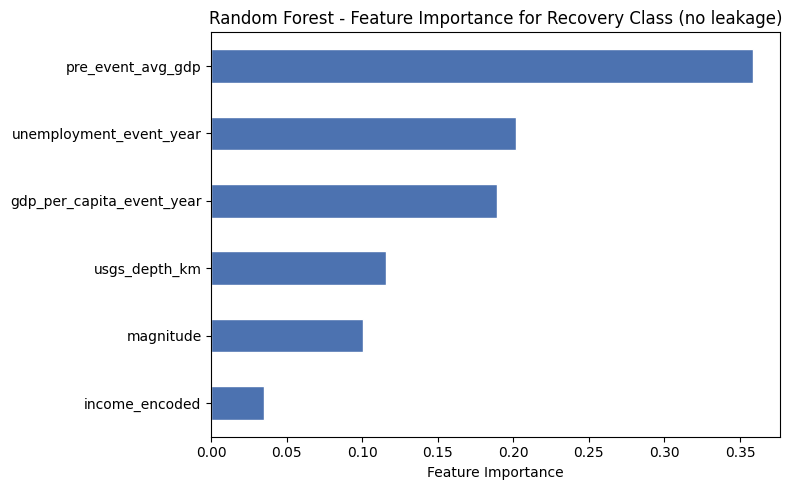


Feature importances:
pre_event_avg_gdp            0.3586
unemployment_event_year      0.2020
gdp_per_capita_event_year    0.1888
usgs_depth_km                0.1155
magnitude                    0.1003
income_encoded               0.0348
dtype: float64


In [35]:
rf_best.fit(X, y)
rf_model = rf_best.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", color="#4c72b0", edgecolor="white", ax=ax)
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest - Feature Importance for Recovery Class (no leakage)")
plt.tight_layout()
import os
os.makedirs("04_machine_learning/outputs", exist_ok=True)
plt.savefig("04_machine_learning/outputs/feature_importance.png", dpi=150)
plt.show()

print("\nFeature importances:")
print(importances.sort_values(ascending=False).round(4))

## 10. Confusion Matrix — where does the model succeed and fail?

Out-of-fold predictions: each row is the true class, each column the predicted class. A perfect model has values only on the diagonal.

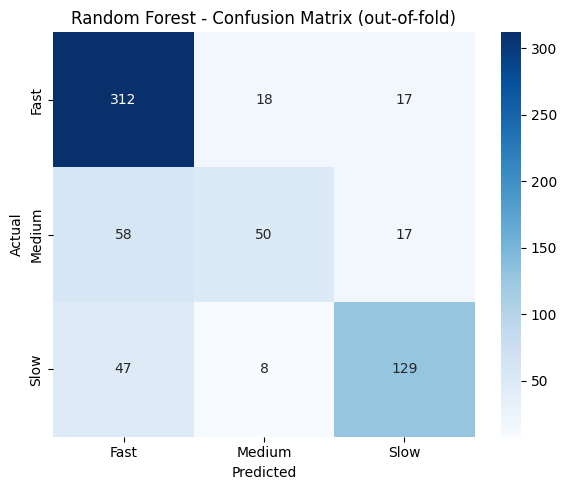


Classification report:
              precision    recall  f1-score   support

        Fast       0.75      0.90      0.82       347
      Medium       0.66      0.40      0.50       125
        Slow       0.79      0.70      0.74       184

    accuracy                           0.75       656
   macro avg       0.73      0.67      0.69       656
weighted avg       0.74      0.75      0.74       656



In [36]:
y_pred_oof = cross_val_predict(rf_best, X, y, cv=cv)
labels = ["Fast", "Medium", "Slow"]
cm = confusion_matrix(y, y_pred_oof, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest - Confusion Matrix (out-of-fold)")
plt.tight_layout()
plt.savefig("04_machine_learning/outputs/confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification report:")
print(classification_report(y, y_pred_oof, labels=labels, zero_division=0))

## Model Comparison Bar Chart

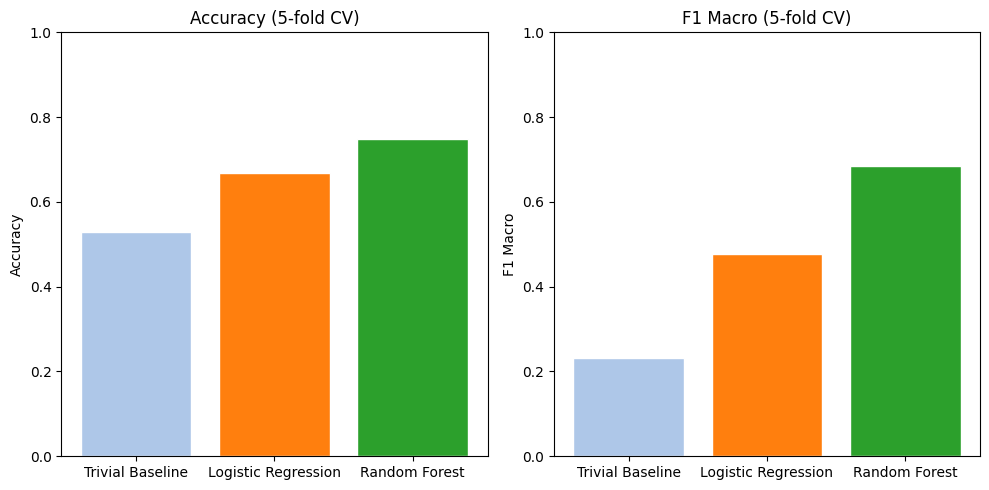

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

models = ["Trivial Baseline", "Logistic Regression", "Random Forest"]
accs = [dummy_acc, lr_acc.mean(), rf_acc.mean()]
f1s  = [dummy_f1,  lr_f1.mean(),  rf_f1.mean()]
colors = ["#aec7e8", "#ff7f0e", "#2ca02c"]

axes[0].bar(models, accs, color=colors, edgecolor="white")
axes[0].set_title("Accuracy (5-fold CV)")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")

axes[1].bar(models, f1s, color=colors, edgecolor="white")
axes[1].set_title("F1 Macro (5-fold CV)")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 Macro")

plt.tight_layout()
plt.savefig("04_machine_learning/outputs/model_comparison.png", dpi=150)
plt.show()

## 11. Summary & Conclusion

In [38]:
print("=" * 60)
print("H3 HYPOTHESIS TEST RESULTS  (Patika A, no leakage)")
print("=" * 60)
print(f"\n{'Model':<25} {'Accuracy':>10} {'F1_macro':>10}")
print("-" * 47)
for _, row in results.iterrows():
    print(f"{row['Model']:<25} {row['Accuracy']:>10.4f} {row['F1_macro']:>10.4f}")
print("-" * 47)

delta_acc = (rf_acc.mean() - lr_acc.mean()) * 100
delta_f1  = (rf_f1.mean()  - lr_f1.mean())  * 100
print(f"\nRF vs Logistic Regression:")
print(f"  Accuracy  delta : {delta_acc:+.2f} percentage points")
print(f"  F1 (macro) delta: {delta_f1:+.2f} percentage points")
print(f"  Paired Wilcoxon p: {p:.4f}")

print(f"\nTop predictors (post-fix, no leakage):")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat:<30} {imp:.4f}")

print("\nConclusion:")
if p < 0.05 and delta_f1 > 1:
    print("  H3 is SUPPORTED with statistical significance.")
    print("  Random Forest captures non-linear structure that Logistic Regression")
    print("  cannot, with a meaningful effect size.")
elif p < 0.05:
    print("  H3 is WEAKLY SUPPORTED: significant but small effect.")
else:
    print("  H3 is NOT clearly supported: RF advantage is within noise.")

H3 HYPOTHESIS TEST RESULTS  (Patika A, no leakage)

Model                       Accuracy   F1_macro
-----------------------------------------------
Trivial baseline              0.5290     0.2306
Logistic Regression           0.6677     0.4769
Random Forest (tuned)         0.7485     0.6846
-----------------------------------------------

RF vs Logistic Regression:
  Accuracy  delta : +8.08 percentage points
  F1 (macro) delta: +20.76 percentage points
  Paired Wilcoxon p: 0.0312

Top predictors (post-fix, no leakage):
  pre_event_avg_gdp              0.3586
  unemployment_event_year        0.2020
  gdp_per_capita_event_year      0.1888
  usgs_depth_km                  0.1155
  magnitude                      0.1003
  income_encoded                 0.0348

Conclusion:
  H3 is SUPPORTED with statistical significance.
  Random Forest captures non-linear structure that Logistic Regression
  cannot, with a meaningful effect size.


## 12. Save Results

In [39]:
results_df = pd.DataFrame({
    "model":     ["Trivial baseline", "Logistic Regression", "Random Forest"],
    "accuracy":  [dummy_acc, lr_acc.mean(), rf_acc.mean()],
    "f1_macro":  [dummy_f1,  lr_f1.mean(),  rf_f1.mean()],
    "acc_std":   [0.0,       lr_acc.std(),  rf_acc.std()],
    "f1_std":    [0.0,       lr_f1.std(),   rf_f1.std()],
})
results_df.to_csv("04_machine_learning/outputs/ml_results.csv", index=False)

importance_df = importances.sort_values(ascending=False).reset_index()
importance_df.columns = ["feature", "importance"]
importance_df.to_csv("04_machine_learning/outputs/feature_importance.csv", index=False)

print("Saved -> 04_machine_learning/outputs/ml_results.csv")
print("Saved -> 04_machine_learning/outputs/feature_importance.csv")
print("Saved -> 04_machine_learning/outputs/confusion_matrix.png")
print("Saved -> 04_machine_learning/outputs/feature_importance.png")

Saved -> 04_machine_learning/outputs/ml_results.csv
Saved -> 04_machine_learning/outputs/feature_importance.csv
Saved -> 04_machine_learning/outputs/confusion_matrix.png
Saved -> 04_machine_learning/outputs/feature_importance.png


In [40]:
import shutil
shutil.copy('04_machine_learning/outputs/ml_results.csv',
            '03_hypothesis_testing/hypothesis/H3/H3_results.csv')
shutil.copy('04_machine_learning/outputs/model_comparison.png',
            '03_hypothesis_testing/hypothesis/H3/H3_plot.png')
shutil.copy('04_machine_learning/outputs/confusion_matrix.png',
            '03_hypothesis_testing/hypothesis/H3/H3_confusion_matrix.png')
print("H3 results copied to 03_hypothesis_testing/H3/")

H3 results copied to 03_hypothesis_testing/H3/


---

## Personal Notes & Additions

- Reframed target as 3-class classification after observing RMSE was misleading for bounded integer outcomes
- Removed gdp_drop from features after identifying it was derived from the same GDP series as the target
- Added trivial baseline to contextualize model performance
- Used stratified 5-fold CV for more reliable evaluation

## AI Usage Statement

AI assistance (Claude by Anthropic) was used in this notebook in the following ways:

- **Diagnosis**: AI identified the target leakage between `gdp_drop` and `recovery_years` after the first version was reviewed.
- **Methodology fix**: AI proposed the 3-class reframing, the trivial baseline, and the paired Wilcoxon significance test.
- **Code structure**: The notebook structure was built interactively with AI guidance.
- **Metric interpretation**: AI explained the meaning of macro-F1 and confusion matrices in the context of imbalanced multi-class classification.

The hypothesis (H3), the decision to keep `recovery_years` as the outcome of interest, and the final interpretation of results were decided by me.